In [5]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In [6]:
IMG_SIZE = (224,224)
BATCH_SIZE = 16
TRAIN_DIR = "data/train"  
VAL_DIR = "data/val"

In [7]:
def build_transfer_model(input_shape=IMG_SIZE+(3,)):
    base = tf.keras.applications.VGG16(weights='imagenet', include_top=False, input_shape=input_shape)
    base.trainable = False
    x = layers.Flatten()(base.output)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    out = layers.Dense(1, activation='sigmoid')(x)
    model = models.Model(inputs=base.input, outputs=out)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

In [8]:
def build_small_cnn(input_shape=IMG_SIZE+(3,)):
    model = models.Sequential([
        layers.Conv2D(32,3,activation='relu', input_shape=input_shape),
        layers.MaxPooling2D(),
        layers.Conv2D(64,3,activation='relu'),
        layers.MaxPooling2D(),
        layers.Conv2D(128,3,activation='relu'),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

In [9]:
def get_generators():
    train_datagen = ImageDataGenerator(rescale=1./255, horizontal_flip=True, rotation_range=20)
    val_datagen = ImageDataGenerator(rescale=1./255)
    train_gen = train_datagen.flow_from_directory(TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary')
    val_gen = val_datagen.flow_from_directory(VAL_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary')
    return train_gen, val_gen

In [10]:
def plot_both(hist1, hist2):
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(hist1.history['accuracy'], label='TL train acc')
    plt.plot(hist1.history['val_accuracy'], label='TL val acc')
    plt.legend(); plt.title('Transfer Learning Acc')
    plt.subplot(1,2,2)
    plt.plot(hist2.history['accuracy'], label='Scratch train acc')
    plt.plot(hist2.history['val_accuracy'], label='Scratch val acc')
    plt.legend(); plt.title('Scratch Acc')
    plt.savefig("transfer_vs_scratch_acc.png", dpi=150)
    print("Saved transfer_vs_scratch_acc.png")

In [11]:
train_gen, val_gen = get_generators()
tl_model = build_transfer_model()
EPOCHS = 5

Found 531 images belonging to 2 classes.
Found 26 images belonging to 2 classes.


In [12]:
hist_tl = tl_model.fit(train_gen, epochs=EPOCHS, validation_data=val_gen)
tl_model.save("vgg16_transfer_head.keras")

c:\Program Files\Python310\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
34/34 ━━━━━━━━━━━━━━━━━━━━ 28s 797ms/step - accuracy: 0.6309 - loss: 2.0951 - val_accuracy: 0.8846 - val_loss: 0.2097
Epoch 2/5
34/34 ━━━━━━━━━━━━━━━━━━━━ 27s 793ms/step - accuracy: 0.8079 - loss: 0.4623 - val_accuracy: 0.9615 - val_loss: 0.1920
Epoch 3/5
34/34 ━━━━━━━━━━━━━━━━━━━━ 29s 858ms/step - accuracy: 0.8550 - loss: 0.3355 - val_accuracy: 1.0000 - val_loss: 0.1476
Epoch 4/5
34/34 ━━━━━━━━━━━━━━━━━━━━ 33s 956ms/step - accuracy: 0.8776 - loss: 0.2813 - val_accuracy: 0.9231 - val_loss: 0.1983
Epoch 5/5
34/34 ━━━━━━━━━━━━━━━━━━━━ 51s 2s/step - accuracy: 0.9077 - loss: 0.2303 - val_accuracy: 0.9231 - val_loss: 0.1602


In [13]:
scratch = build_small_cnn()
hist_scratch = scratch.fit(train_gen, epochs=EPOCHS, validation_data=val_gen)
scratch.save("small_cnn_scratch.keras")

c:\Program Files\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
34/34 ━━━━━━━━━━━━━━━━━━━━ 11s 299ms/step - accuracy: 0.5085 - loss: 0.7881 - val_accuracy: 0.5000 - val_loss: 0.7021
Epoch 2/5
34/34 ━━━━━━━━━━━━━━━━━━━━ 10s 288ms/step - accuracy: 0.5763 - loss: 0.6739 - val_accuracy: 0.5385 - val_loss: 0.6282
Epoch 3/5
34/34 ━━━━━━━━━━━━━━━━━━━━ 9s 274ms/step - accuracy: 0.6045 - loss: 0.6566 - val_accuracy: 0.6923 - val_loss: 0.5623
Epoch 4/5
34/34 ━━━━━━━━━━━━━━━━━━━━ 10s 282ms/step - accuracy: 0.6158 - loss: 0.6501 - val_accuracy: 0.7308 - val_loss: 0.5236
Epoch 5/5
34/34 ━━━━━━━━━━━━━━━━━━━━ 10s 289ms/step - accuracy: 0.6591 - loss: 0.6305 - val_accuracy: 0.6923 - val_loss: 0.6074


Saved transfer_vs_scratch_acc.png


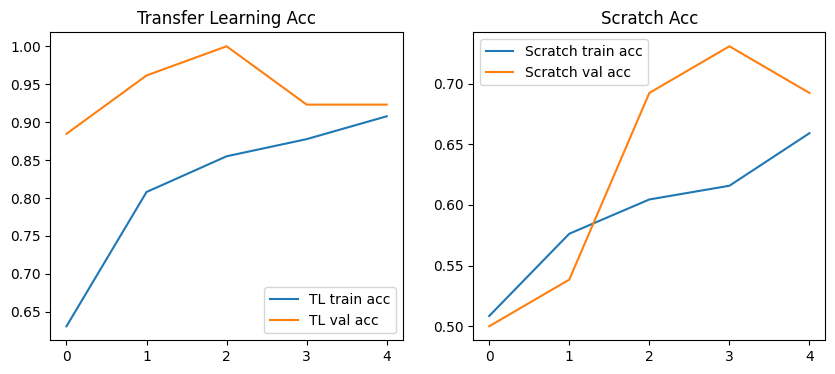

In [14]:
plot_both(hist_tl, hist_scratch)